# Settings

## Import packages

In [2]:
import pandas as pd
import numpy as np
import json
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
import math
import itertools
import geopandas as gpd
import matplotlib.patches as mpatches
import requests
import time

from scipy import stats
from scipy.stats import chi2_contingency, pointbiserialr
from geopy.geocoders import Nominatim
from shapely.geometry import Point
from matplotlib.patches import Circle

pd.set_option('display.precision', 4)

## Self-defined functions

In [14]:
def gen_subgrids(error_grid_df, last_radius):
    """
    Generate 4 subgrid points around each (lat, lon) using half of the previous radius.

    Parameters:
    - error_grid_df: DataFrame with 'lat' and 'lon' columns
    - last_radius: Previous radius in meters

    Returns:
    - next_radius: New suggested radius for next round (offset * sqrt(2))
    - subgrid_df: DataFrame with new subgrid points and metadata
    """
    offset = last_radius / 2
    meters_per_deg_lat = 111000
    meters_per_deg_lon = 85000

    subgrid_rows = []

    offsets = [
        (+offset, +offset),
        (+offset, -offset),
        (-offset, +offset),
        (-offset, -offset),
    ]
    
    for idx, row in error_grid_df.iterrows():
        lat0 = row['lat']
        lon0 = row['lon']
        for dx, dy in offsets:
            lat = round(lat0 + dy / meters_per_deg_lat, 5)
            lon = round(lon0 + dx / meters_per_deg_lon, 5)
            subgrid_rows.append({
                'lat': lat,
                'lon': lon,
                'source': f'subgrid from ({lat0:.4f}, {lon0:.4f})',
                'processed': False,
                'new_records': 0,
                'error': None
            })

    subgrid_df = pd.DataFrame(subgrid_rows)
    next_radius = int(np.ceil(offset * math.sqrt(2)))
    return next_radius, subgrid_df

In [ ]:
def fetch_yelp_data_by_radius(api_key, grid_df, yelp_df, seen_ids, radius):
    """
    Fetches Yelp restaurant data for each grid center within a given radius.

    Parameters:
        api_key (str): Yelp Fusion API key.
        grid_df (pd.DataFrame): Grid points with 'lat', 'lon', and tracking columns.
        yelp_df (pd.DataFrame): DataFrame to accumulate business records.
        seen_ids (set): Set of already seen business IDs to avoid duplicates.
        radius (int): Search radius in meters.

    Returns:
        tuple: Updated (grid_df, yelp_df, seen_ids)
    """
    headers = {
        'Authorization': f'Bearer {api_key}',
    }

    for i, row in grid_df.iterrows():
        if row['processed']:
            continue
    
        if i % 100 == 0:
            timestamp = datetime.datetime.now().strftime('%Y%m%d_%H%M%S')
            record_count = len(yelp_df)
            filename = f'yelp_manhattan_{record_count}_{timestamp}_.csv'
            yelp_df.to_csv(filename, index=False)
    
        lat_center, lon_center = row['lat'], row['lon']
        print(f"[{i+1}/{len(grid_df)}] Grid center: ({lat_center}, {lon_center})")
    
        total_new = 0
        error_message = None
    
        for offset in range(0, 200, 50):
            params = {
                'term': 'restaurants',
                'latitude': lat_center,
                'longitude': lon_center,
                'radius': radius,
                'limit': 50,
                'offset': offset,
                'sort_by': 'distance'
            }
    
            try:
                response = requests.get('https://api.yelp.com/v3/businesses/search',
                                        headers=headers, params=params)
    
                if response.status_code != 200:
                    error_message = f"{response.status_code}: {response.text}"
                    print("Error:", error_message)
                    break
    
                data = response.json()
                businesses = data.get('businesses', [])            
    
                if not businesses:
                    print(f'No record @({lat_center}, {lon_center})')
                    break
    
                
    
                if len(businesses) < 50:
                    reached_last_page = True
                else:
                    reached_last_page = False
    
                df_chunk = pd.json_normalize(businesses)
                
                if not df_chunk.empty and 'id' in df_chunk.columns:
                    df_chunk = df_chunk[~df_chunk['id'].isin(seen_ids)]
                
                    if not df_chunk.empty:
                        seen_ids.update(df_chunk['id'].tolist())
                        yelp_df = pd.concat([yelp_df, df_chunk], ignore_index=True)
                        total_new += df_chunk.shape[0]
                
                print(f"{len(businesses)} records for offset {offset} @({lat_center}, {lon_center}) - {df_chunk.shape[0]}")
                
                if reached_last_page:
                    break
    
                if offset == 150 and len(businesses) == 50:
                    error_message = "Too many results: likely to exceed 240 limit"
                    print("Error:", error_message)
                    break
    
                time.sleep(0.1)
    
            except Exception as e:
                error_message = str(e)
                print("Exception:", error_message)
                break
    
        print(f"{total_new} new records @({lat_center}, {lon_center})")
        # 更新 grid_df 對應列
        grid_df.at[i, 'processed'] = True
        grid_df.at[i, 'new_records'] = total_new
        grid_df.at[i, 'error'] = error_message

    print(f"✅ Total unique restaurants collected: {len(yelp_df)}")
    timestamp = datetime.datetime.now().strftime('%Y%m%d_%H%M%S')
    record_count = len(yelp_df)
    filename = f'yelp_manhattan_{record_count}_{timestamp}_.csv'
    yelp_df.to_csv(filename, index=False)

    return grid_df, yelp_df, seen_ids

# Yelp Fusion API
- Apply for an API key:
  1. Create an account: https://www.yelp.com/signup
  2. Create an app: https://www.yelp.com/developers/v3/manage_app
  3. Comfirm the email and get the API key from https://www.yelp.com/developers/v3/manage_app 
- Documentation: https://docs.developer.yelp.com/reference/v3_business_search

In [ ]:
api_key = '' # Put your API Key here❗️❗️❗️❗️
headers = {
    'Authorization': f'Bearer {api_key}',
}

## Step 1: Preliminary Grid Generation with Step = 0.005 and Radius = 400m
To begin the spatial analysis, we first generated a preliminary grid overlay for Manhattan. The grid was created by iterating over latitude and longitude with a step size of 0.005 degrees, which roughly corresponds to ~550 meters in distance. This granularity was chosen to balance coverage and computational efficiency for initial data exploration.

Each center point of the grid cells was used to construct a circular search area with a radius of 400 meters, approximating walkable or local influence zones. These zones were then used to query and collect preliminary data for Manhattan, including event locations, bike stations, and other spatially referenced features.

This step is primarily intended to verify data availability and spatial alignment before applying the same method on a larger or more precise scale.

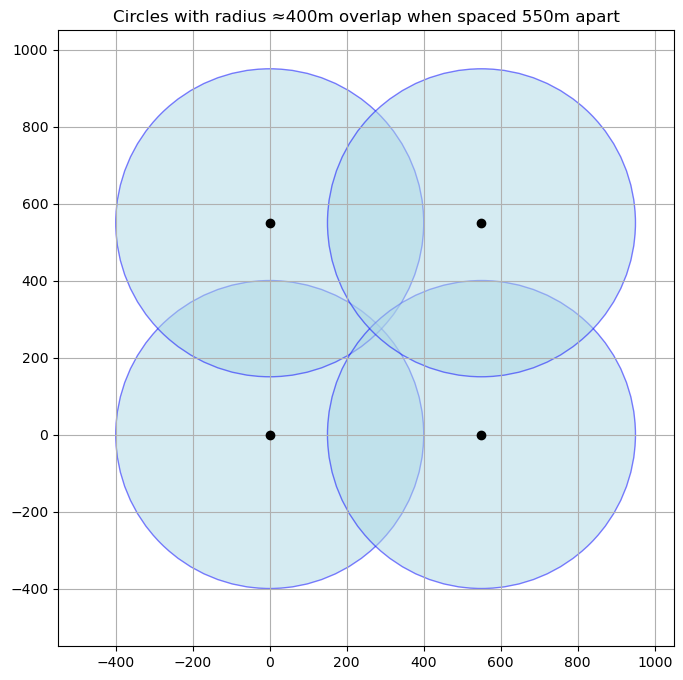

In [4]:
fig, ax = plt.subplots(figsize=(8, 8))

r = 550
centers = [(0, 0),
           (0, r),
           (r, 0),
           (r, r)]


r_radius = 400
for x, y in centers:
    circle = Circle((x, y), r_radius, edgecolor='blue', facecolor='lightblue', alpha=0.5)
    ax.add_patch(circle)
    ax.plot(x, y, 'ko')  # 圓心

ax.set_xlim(-r, r + r_radius + 100)
ax.set_ylim(-r, r + r_radius + 100)
ax.set_aspect('equal')
ax.set_title(f"Circles with radius ≈{r_radius}m overlap when spaced {r}m apart")
plt.grid(True)
plt.show()

In [5]:
# Latitude and lontitude for Manhattan
lat_min, lat_max = 40.70, 40.88
lon_min, lon_max = -74.02, -73.92
grid_step = 0.005  # ~550m

lat_points = np.arange(lat_min, lat_max, grid_step)
lon_points = np.arange(lon_min, lon_max, grid_step)
grid_centers = [(np.round(lat, 3), np.round(lon, 3)) for lat in lat_points for lon in lon_points]

grid_df = pd.DataFrame(grid_centers, columns=['lat', 'lon'])
grid_df['processed'] = False
grid_df['new_records'] = 0
grid_df['error'] = None

grid_df.head()
display(grid_df)

,lat,lon,processed,new_records,error
0,40.700,-74.020,False,0,None
1,40.700,-74.015,False,0,None
2,40.700,-74.010,False,0,None
3,40.700,-74.005,False,0,None
4,40.700,-74.000,False,0,None
...,...,...,...,...,...
715,40.875,-73.945,False,0,None
716,40.875,-73.940,False,0,None
717,40.875,-73.935,False,0,None
718,40.875,-73.930,False,0,None


In [ ]:
# # The code below was previously executed, and the resulting data has already been saved to CSV files.
# # To prevent unnecessary re-execution and preserve results, the code has been converted to comments.
# yelp_df = pd.DataFrame()
# seen_ids = set()
# grid_df, yelp_df, seen_ids = fetch_yelp_data_by_radius(api_key=api_key,
#                                                        grid_df=grid_df,
#                                                        yelp_df=yelp_df,
#                                                        seen_ids=seen_ids,
#                                                        radius=400)

# # Save the current progress to csv
# print(f"✅ Total unique restaurants collected: {len(yelp_df)}")
# record_count = len(yelp_df)
# filename = f'yelp_manhattan_step1_{record_count}.csv'
# yelp_df.to_csv(filename, index=False)

# filename = f'grid_df_step1_{record_count}.csv'
# grid_df.to_csv(filename, index=False)

In [10]:
yelp_df = pd.read_csv('yelp_manhattan_step1_18339.csv')
grid_df = pd.read_csv('grid_df_step1_18339.csv')

In [11]:
# 147 locations may need further exploration since the resuls exceed 240 limit
grid_df[grid_df['error'].notna()]

,lat,lon,processed,new_records,error
18,40.700,-73.930,True,81,Too many results: likely to exceed 240 limit
19,40.700,-73.925,True,81,Too many results: likely to exceed 240 limit
21,40.705,-74.015,True,33,Too many results: likely to exceed 240 limit
22,40.705,-74.010,True,41,Too many results: likely to exceed 240 limit
23,40.705,-74.005,True,109,Too many results: likely to exceed 240 limit
...,...,...,...,...,...
411,40.800,-73.965,True,18,Too many results: likely to exceed 240 limit
416,40.800,-73.940,True,34,Too many results: likely to exceed 240 limit
454,40.810,-73.950,True,23,Too many results: likely to exceed 240 limit
514,40.825,-73.950,True,41,Too many results: likely to exceed 240 limit


## Step 2: Refine Error Locations by Dividing into 4 Subgrids

For each failed grid (with API error or too many results), generate 4 smaller subgrids by offsetting half the radius in four directions (↗️, ↖️, ↘️, ↙️). This helps recover data missed in the initial pass.

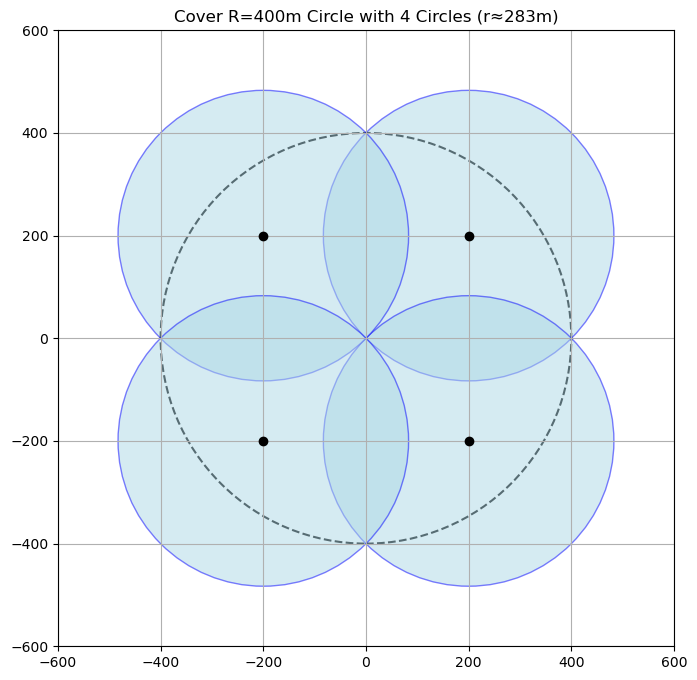

In [12]:
R_big = 400

fig, ax = plt.subplots(figsize=(8, 8))
big_circle = Circle((0, 0), R_big, edgecolor='black', facecolor='none', linestyle='--', linewidth=1.5)
ax.add_patch(big_circle)

r = 200
centers = [(r, r),
           (r, -r),
           (-r, r),
           (-r, -r)]


r_radius = int(np.ceil(r * math.sqrt(2)))
for x, y in centers:
    circle = Circle((x, y), r_radius, edgecolor='blue', facecolor='lightblue', alpha=0.5)
    ax.add_patch(circle)
    ax.plot(x, y, 'ko')

ax.set_xlim(-R_big - r, R_big + r)
ax.set_ylim(-R_big - r, R_big + r)
ax.set_aspect('equal')
ax.set_title(f"Cover R={R_big}m Circle with 4 Circles (r≈{r_radius}m)")
plt.grid(True)
plt.show()

In [15]:
radius_v2, grid_df_v2 = gen_subgrids(error_grid_df=grid_df[grid_df['error'].notna()], 
                                     last_radius=400)
# The next radius is 283m
display(radius_v2)

# 588 locations to be checked
display(grid_df_v2)

283

,lat,lon,source,processed,new_records,error
0,40.7018,-73.9276,"subgrid from (40.7000, -73.9300)",False,0,None
1,40.6982,-73.9276,"subgrid from (40.7000, -73.9300)",False,0,None
2,40.7018,-73.9323,"subgrid from (40.7000, -73.9300)",False,0,None
3,40.6982,-73.9323,"subgrid from (40.7000, -73.9300)",False,0,None
4,40.7018,-73.9227,"subgrid from (40.7000, -73.9250)",False,0,None
...,...,...,...,...,...,...
583,40.8232,-73.9523,"subgrid from (40.8250, -73.9500)",False,0,None
584,40.8268,-73.9427,"subgrid from (40.8250, -73.9450)",False,0,None
585,40.8232,-73.9427,"subgrid from (40.8250, -73.9450)",False,0,None
586,40.8268,-73.9474,"subgrid from (40.8250, -73.9450)",False,0,None


In [ ]:
# # The code below was previously executed, and the resulting data has already been saved to CSV files.
# # To prevent unnecessary re-execution and preserve results, the code has been converted to comments.
    
# grid_df_v2, yelp_df, seen_ids = fetch_yelp_data_by_radius(api_key='Your API key', 
#                                                           grid_df=grid_df_v2, 
#                                                           yelp_df=yelp_df, 
#                                                           seen_ids=seen_ids, 
#                                                           radius=radius_v2)

# # Save the current progress to csv
# print(f"✅ Total unique restaurants collected: {len(yelp_df)}")
# record_count = len(yelp_df)
# filename = f'yelp_manhattan_step2_{record_count}.csv'
# yelp_df.to_csv(filename, index=False)

# filename = f'grid_df_step2_{record_count}.csv'
# grid_df_v2.to_csv(filename, index=False)

In [22]:
grid_df_v2 = pd.read_csv('grid_df_step2_18731.csv')
yelp_df = pd.read_csv('yelp_manhattan_step2_18731.csv')

In [23]:
# 532 locations may need further exploration
grid_df_v2[grid_df_v2['error'].notna()]

,lat,lon,source,processed,new_records,error
0,40.7018,-73.9276,"subgrid from (40.7000, -73.9300)",True,0,Too many results: likely to exceed 240 limit
4,40.7018,-73.9227,"subgrid from (40.7000, -73.9250)",True,13,Too many results: likely to exceed 240 limit
5,40.6982,-73.9227,"subgrid from (40.7000, -73.9250)",True,38,Too many results: likely to exceed 240 limit
6,40.7018,-73.9274,"subgrid from (40.7000, -73.9250)",True,0,Too many results: likely to exceed 240 limit
8,40.7068,-74.0126,"subgrid from (40.7050, -74.0150)",True,0,Too many results: likely to exceed 240 limit
...,...,...,...,...,...,...
583,40.8232,-73.9523,"subgrid from (40.8250, -73.9500)",True,0,"429: {""error"": {""code"": ""ACCESS_LIMIT_REACHED""..."
584,40.8268,-73.9427,"subgrid from (40.8250, -73.9450)",True,0,"429: {""error"": {""code"": ""ACCESS_LIMIT_REACHED""..."
585,40.8232,-73.9427,"subgrid from (40.8250, -73.9450)",True,0,"429: {""error"": {""code"": ""ACCESS_LIMIT_REACHED""..."
586,40.8268,-73.9474,"subgrid from (40.8250, -73.9450)",True,0,"429: {""error"": {""code"": ""ACCESS_LIMIT_REACHED""..."
